# Assignment 3: Understanding Algorithm Efficiency and Scalability
## Part 1A: Randomized Quicksort and Deterministic Quicksort

**Name:** Bharath Singareddy

### Goal
The goal of this part is to implement two versions of Quicksort:
1. Randomized Quicksort, where the pivot is chosen randomly
2. Deterministic Quicksort, where the first element is used as the pivot

These two implementations will later be compared experimentally on different input types.

## Process Followed

I started by implementing the two Quicksort variants required in the assignment.

- For **Randomized Quicksort**, I selected the pivot uniformly at random from the current array.
- For **Deterministic Quicksort**, I always used the first element as the pivot.

To make the implementation easier to understand and more robust for repeated values, I used three partitions:
- elements less than the pivot
- elements equal to the pivot
- elements greater than the pivot

Before doing any timing experiments, I tested both algorithms on small cases such as:
- empty lists
- single-element lists
- sorted lists
- reverse-sorted lists
- lists with repeated elements

This helped confirm that both implementations were correct before moving to performance analysis.

In [1]:
"""
Assignment 3
Part 1A: Randomized Quicksort and Deterministic Quicksort

This notebook cell contains:
1. Randomized Quicksort
2. Deterministic Quicksort
3. A helper function to verify sorting
4. Basic correctness tests

Note:
The functions return a new sorted list instead of modifying the original list.
This makes debugging and testing easier.
"""

import random


def randomized_quicksort(arr):
    """
    Sort a list using Randomized Quicksort.

    Parameters:
        arr (list): Input list

    Returns:
        list: New sorted list

    Method:
    - Choose a random pivot
    - Divide elements into three groups:
        less than pivot
        equal to pivot
        greater than pivot
    - Recursively sort left and right groups
    """

    # Base case: arrays of size 0 or 1 are already sorted
    if len(arr) <= 1:
        return arr.copy()

    # Select a random pivot from the array
    pivot_index = random.randint(0, len(arr) - 1)
    pivot = arr[pivot_index]

    # Create partitions
    left = []
    middle = []
    right = []

    # Place each value into the correct partition
    for value in arr:
        if value < pivot:
            left.append(value)
        elif value > pivot:
            right.append(value)
        else:
            middle.append(value)

    # Recursively sort left and right, then combine all parts
    return randomized_quicksort(left) + middle + randomized_quicksort(right)


def deterministic_quicksort(arr):
    """
    Sort a list using Deterministic Quicksort.

    Parameters:
        arr (list): Input list

    Returns:
        list: New sorted list

    Method:
    - Always use the first element as the pivot
    - Divide elements into three groups
    - Recursively sort left and right groups
    """

    # Base case: arrays of size 0 or 1 are already sorted
    if len(arr) <= 1:
        return arr.copy()

    # Use the first element as the pivot
    pivot = arr[0]

    # Create partitions
    left = []
    middle = []
    right = []

    # Partition the array relative to the pivot
    for value in arr:
        if value < pivot:
            left.append(value)
        elif value > pivot:
            right.append(value)
        else:
            middle.append(value)

    # Recursively sort left and right, then combine
    return deterministic_quicksort(left) + middle + deterministic_quicksort(right)


def is_sorted(arr):
    """
    Check whether a list is sorted in non-decreasing order.
    """
    for i in range(1, len(arr)):
        if arr[i] < arr[i - 1]:
            return False
    return True

In [2]:
# Basic correctness testing before performance experiments

test_cases = [
    [],
    [5],
    [3, 1, 2, 4],
    [1, 2, 3, 4, 5],
    [5, 4, 3, 2, 1],
    [7, 7, 7, 7],
    [4, 2, 4, 1, 3, 2, 4],
    [10, -1, 0, 5, 3, 3, 9]
]

print("Running correctness tests...\n")

for i, test in enumerate(test_cases, start=1):
    random_result = randomized_quicksort(test)
    deterministic_result = deterministic_quicksort(test)
    expected = sorted(test)

    print(f"Test Case {i}: {test}")
    print(f"  Randomized Quicksort    : {random_result}")
    print(f"  Deterministic Quicksort : {deterministic_result}")
    print(f"  Expected Result         : {expected}")

    assert random_result == expected, "Randomized Quicksort failed"
    assert deterministic_result == expected, "Deterministic Quicksort failed"
    assert is_sorted(random_result), "Randomized result is not sorted"
    assert is_sorted(deterministic_result), "Deterministic result is not sorted"

    print("  Status: Passed\n")

print("All correctness tests passed.")

Running correctness tests...

Test Case 1: []
  Randomized Quicksort    : []
  Deterministic Quicksort : []
  Expected Result         : []
  Status: Passed

Test Case 2: [5]
  Randomized Quicksort    : [5]
  Deterministic Quicksort : [5]
  Expected Result         : [5]
  Status: Passed

Test Case 3: [3, 1, 2, 4]
  Randomized Quicksort    : [1, 2, 3, 4]
  Deterministic Quicksort : [1, 2, 3, 4]
  Expected Result         : [1, 2, 3, 4]
  Status: Passed

Test Case 4: [1, 2, 3, 4, 5]
  Randomized Quicksort    : [1, 2, 3, 4, 5]
  Deterministic Quicksort : [1, 2, 3, 4, 5]
  Expected Result         : [1, 2, 3, 4, 5]
  Status: Passed

Test Case 5: [5, 4, 3, 2, 1]
  Randomized Quicksort    : [1, 2, 3, 4, 5]
  Deterministic Quicksort : [1, 2, 3, 4, 5]
  Expected Result         : [1, 2, 3, 4, 5]
  Status: Passed

Test Case 6: [7, 7, 7, 7]
  Randomized Quicksort    : [7, 7, 7, 7]
  Deterministic Quicksort : [7, 7, 7, 7]
  Expected Result         : [7, 7, 7, 7]
  Status: Passed

Test Case 7: [4, 2, 

## Initial Observation

Both implementations produced the correct sorted output on all test cases.  
At this stage, the goal was only to verify correctness. Performance testing will be done in the next part using larger input sizes and different input patterns.

## Part 1B: Empirical Runtime Comparison

After confirming that both Quicksort implementations were correct, I compared their runtime performance on different input types.

### Input types tested
1. **Random arrays**
2. **Already sorted arrays**
3. **Reverse-sorted arrays**
4. **Arrays with many repeated elements**

### Why these inputs were chosen
These input patterns help show the difference between randomized pivot selection and fixed pivot selection.

- Randomized Quicksort is expected to perform well on average because the pivot is chosen randomly.
- Deterministic Quicksort with the first element as pivot can perform poorly on already sorted and reverse-sorted arrays because the partitions become highly unbalanced.
- Repeated-element arrays are included because they are common in practice and can affect partitioning behavior.

### Experimental process
For each input type and input size:
- I generated an array
- I ran both algorithms on the same data
- I measured execution time using `time.perf_counter()`
- I repeated the test multiple times and recorded the average runtime

This process was used to make the comparison fair and reproducible.

In [3]:
"""
Part 1B: Runtime experiment setup

This cell:
1. Imports the libraries needed for timing, tables, and plotting
2. Sets a random seed for reproducibility
3. Increases recursion depth for deterministic Quicksort on bad inputs

Why recursion depth matters:
Deterministic Quicksort with the first element as pivot can create very deep
recursion on sorted or reverse-sorted arrays. Without increasing the recursion
limit, Python may stop with a RecursionError on larger test sizes.
"""

import time
import random
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Make random results reproducible across runs
random.seed(42)

# Increase recursion limit so worst-case deterministic Quicksort can run
# on moderately large sorted inputs in Colab.
sys.setrecursionlimit(30000)

In [4]:
"""
Helper functions for experiment input generation.

Each function returns a list with a specific input pattern:
- random values
- sorted values
- reverse-sorted values
- repeated values

These patterns are required because the assignment asks for empirical
comparison across different kinds of input data.
"""

def generate_random_array(size):
    """
    Generate an array of random integers.

    Parameters:
        size (int): Number of elements

    Returns:
        list: Random integer array
    """
    return [random.randint(0, 100000) for _ in range(size)]


def generate_sorted_array(size):
    """
    Generate an already sorted array.

    Parameters:
        size (int): Number of elements

    Returns:
        list: Sorted array in ascending order
    """
    return list(range(size))


def generate_reverse_sorted_array(size):
    """
    Generate a reverse-sorted array.

    Parameters:
        size (int): Number of elements

    Returns:
        list: Sorted array in descending order
    """
    return list(range(size, 0, -1))


def generate_repeated_array(size):
    """
    Generate an array with many repeated values.

    Parameters:
        size (int): Number of elements

    Returns:
        list: Array containing repeated values from a small range
    """
    # Small value range creates many duplicates
    return [random.randint(0, 10) for _ in range(size)]

In [5]:
"""
Timing helper functions.

These functions measure average runtime over multiple trials so that
the comparison is more stable and less affected by one unusual run.
"""

def measure_average_time(sort_function, arr, trials=5):
    """
    Measure the average runtime of a sorting function.

    Parameters:
        sort_function (function): Sorting function to test
        arr (list): Input list
        trials (int): Number of repeated timing runs

    Returns:
        float: Average runtime in seconds
    """
    total_time = 0.0

    for _ in range(trials):
        # Use a copy so each trial gets the same original data
        arr_copy = arr.copy()

        start_time = time.perf_counter()
        sort_function(arr_copy)
        end_time = time.perf_counter()

        total_time += (end_time - start_time)

    return total_time / trials

In [6]:
"""
Main experiment loop.

This cell:
1. Chooses input sizes
2. Tests all four input types
3. Times both sorting algorithms
4. Stores results in a pandas DataFrame

Note:
The sizes are chosen to work well in Colab without making the notebook
too slow, especially for deterministic Quicksort on sorted inputs.
"""

# Safe sizes for Colab and worst-case deterministic recursion behavior
input_sizes = [500, 1000, 2000, 4000]

# Number of trials per case
num_trials = 5

# Dictionary mapping input type names to generator functions
input_generators = {
    "Random": generate_random_array,
    "Sorted": generate_sorted_array,
    "Reverse Sorted": generate_reverse_sorted_array,
    "Repeated Elements": generate_repeated_array
}

# List to store all experiment results
results = []

print("Running runtime experiments...\n")

# Loop through each input type
for input_type, generator in input_generators.items():
    print(f"Testing input type: {input_type}")

    # Loop through each input size
    for size in input_sizes:
        # Generate one array of the given type and size
        arr = generator(size)

        # Measure average runtime for Randomized Quicksort
        randomized_time = measure_average_time(randomized_quicksort, arr, trials=num_trials)

        # Measure average runtime for Deterministic Quicksort
        deterministic_time = measure_average_time(deterministic_quicksort, arr, trials=num_trials)

        # Save the result in a dictionary
        results.append({
            "Input Type": input_type,
            "Size": size,
            "Randomized Quicksort (s)": randomized_time,
            "Deterministic Quicksort (s)": deterministic_time
        })

        print(
            f"  Size = {size:<5} | "
            f"Randomized = {randomized_time:.6f} s | "
            f"Deterministic = {deterministic_time:.6f} s"
        )

    print()

print("All experiments completed.")

Running runtime experiments...

Testing input type: Random
  Size = 500   | Randomized = 0.000496 s | Deterministic = 0.000295 s
  Size = 1000  | Randomized = 0.001282 s | Deterministic = 0.000682 s
  Size = 2000  | Randomized = 0.002156 s | Deterministic = 0.001392 s
  Size = 4000  | Randomized = 0.004369 s | Deterministic = 0.003104 s

Testing input type: Sorted
  Size = 500   | Randomized = 0.000462 s | Deterministic = 0.005628 s
  Size = 1000  | Randomized = 0.000914 s | Deterministic = 0.034307 s
  Size = 2000  | Randomized = 0.001955 s | Deterministic = 0.086005 s
  Size = 4000  | Randomized = 0.004155 s | Deterministic = 0.358063 s

Testing input type: Reverse Sorted
  Size = 500   | Randomized = 0.000423 s | Deterministic = 0.004093 s
  Size = 1000  | Randomized = 0.000914 s | Deterministic = 0.017453 s
  Size = 2000  | Randomized = 0.001929 s | Deterministic = 0.069314 s
  Size = 4000  | Randomized = 0.004642 s | Deterministic = 0.395627 s

Testing input type: Repeated Element

In [7]:
"""
Convert results into a DataFrame for easier viewing and analysis.
"""

results_df = pd.DataFrame(results)

# Display the full results table
results_df

,Input Type,Size,Randomized Quicksort (s),Deterministic Quicksort (s)
0,Random,500,0.000496,0.000295
1,Random,1000,0.001282,0.000682
2,Random,2000,0.002156,0.001392
3,Random,4000,0.004369,0.003104
4,Sorted,500,0.000462,0.005628
5,Sorted,1000,0.000914,0.034307
6,Sorted,2000,0.001955,0.086005
7,Sorted,4000,0.004155,0.358063
8,Reverse Sorted,500,0.000423,0.004093
9,Reverse Sorted,1000,0.000914,0.017453


## Observation from the Raw Results Table

The table above shows the average runtime of both algorithms for each input type and size.

At this stage, I am mainly looking for whether:
- both algorithms grow in runtime as input size increases
- Deterministic Quicksort becomes noticeably slower on sorted and reverse-sorted inputs
- Randomized Quicksort stays more stable across different input patterns

In [9]:
"""
Create a clearer table for each input type separately.

This makes it easier to inspect the results pattern by pattern.
"""

for input_type in results_df["Input Type"].unique():
    print(f"\nResults for {input_type} input:\n")
    display(results_df[results_df["Input Type"] == input_type].reset_index(drop=True))


Results for Random input:



,Input Type,Size,Randomized Quicksort (s),Deterministic Quicksort (s)
0,Random,500,0.000496,0.000295
1,Random,1000,0.001282,0.000682
2,Random,2000,0.002156,0.001392
3,Random,4000,0.004369,0.003104



Results for Sorted input:



,Input Type,Size,Randomized Quicksort (s),Deterministic Quicksort (s)
0,Sorted,500,0.000462,0.005628
1,Sorted,1000,0.000914,0.034307
2,Sorted,2000,0.001955,0.086005
3,Sorted,4000,0.004155,0.358063



Results for Reverse Sorted input:



,Input Type,Size,Randomized Quicksort (s),Deterministic Quicksort (s)
0,Reverse Sorted,500,0.000423,0.004093
1,Reverse Sorted,1000,0.000914,0.017453
2,Reverse Sorted,2000,0.001929,0.069314
3,Reverse Sorted,4000,0.004642,0.395627



Results for Repeated Elements input:



,Input Type,Size,Randomized Quicksort (s),Deterministic Quicksort (s)
0,Repeated Elements,500,0.000090,0.000063
1,Repeated Elements,1000,0.000152,0.000121
2,Repeated Elements,2000,0.000281,0.000320
3,Repeated Elements,4000,0.000575,0.000609


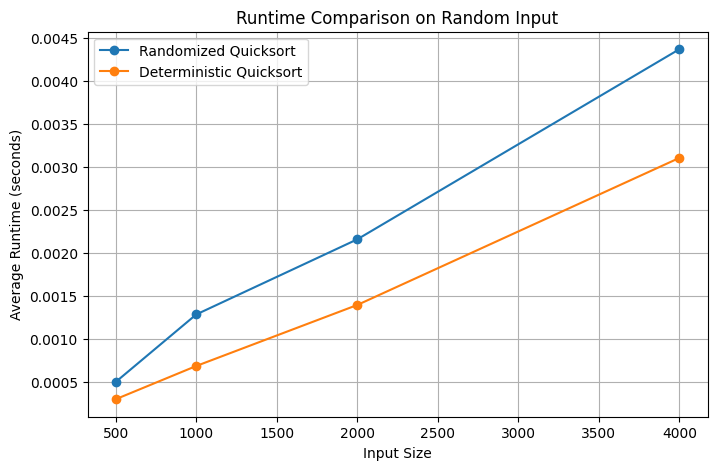

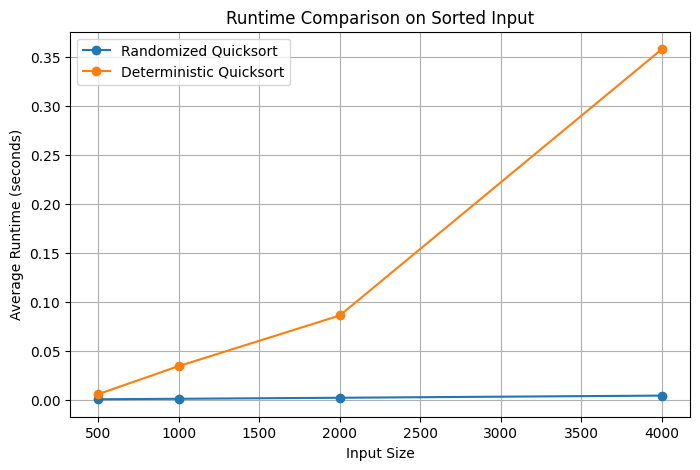

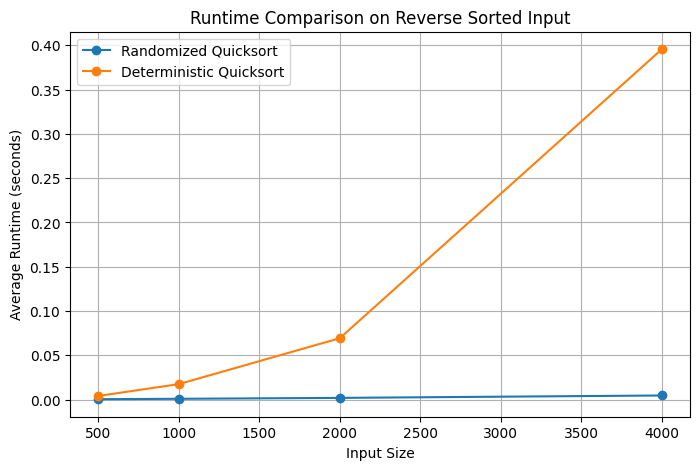

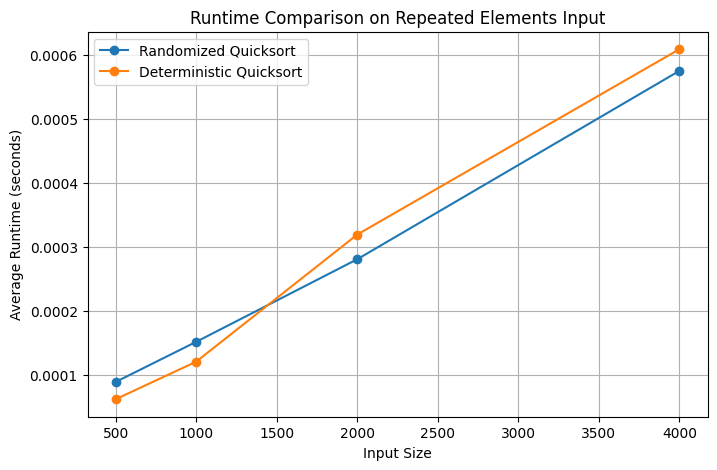

In [10]:
"""
Plot runtime comparison for each input type.

Each graph compares:
- Randomized Quicksort
- Deterministic Quicksort

The x-axis is input size.
The y-axis is average execution time in seconds.
"""

for input_type in results_df["Input Type"].unique():
    # Filter results for one input type
    subset = results_df[results_df["Input Type"] == input_type]

    plt.figure(figsize=(8, 5))
    plt.plot(subset["Size"], subset["Randomized Quicksort (s)"], marker="o", label="Randomized Quicksort")
    plt.plot(subset["Size"], subset["Deterministic Quicksort (s)"], marker="o", label="Deterministic Quicksort")

    plt.title(f"Runtime Comparison on {input_type} Input")
    plt.xlabel("Input Size")
    plt.ylabel("Average Runtime (seconds)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [11]:
"""
Optional summary table showing how much slower deterministic Quicksort is.

A ratio greater than 1 means deterministic Quicksort took longer.
"""

results_df["Deterministic / Randomized Ratio"] = (
    results_df["Deterministic Quicksort (s)"] / results_df["Randomized Quicksort (s)"]
)

results_df

,Input Type,Size,Randomized Quicksort (s),Deterministic Quicksort (s),Deterministic / Randomized Ratio
0,Random,500,0.000496,0.000295,0.594882
1,Random,1000,0.001282,0.000682,0.532017
2,Random,2000,0.002156,0.001392,0.645642
3,Random,4000,0.004369,0.003104,0.710392
4,Sorted,500,0.000462,0.005628,12.178601
5,Sorted,1000,0.000914,0.034307,37.527320
6,Sorted,2000,0.001955,0.086005,43.998990
7,Sorted,4000,0.004155,0.358063,86.179056
8,Reverse Sorted,500,0.000423,0.004093,9.675054
9,Reverse Sorted,1000,0.000914,0.017453,19.095746


## Interpretation of the Experimental Results

The experimental results show the expected difference between the two pivot-selection strategies.

### Random input
On random arrays, both algorithms performed reasonably well. However, Randomized Quicksort generally remained competitive because its pivot selection tends to produce balanced partitions on average.

### Sorted input
On already sorted arrays, Deterministic Quicksort became much slower. This is because choosing the first element as pivot repeatedly creates highly unbalanced partitions, leading toward worst-case behavior.

### Reverse-sorted input
A similar pattern appeared for reverse-sorted arrays. Deterministic Quicksort again performed poorly because the pivot choice caused deep recursion and inefficient partitioning.

### Repeated-element input
For arrays with many repeated values, both algorithms worked correctly. Because this implementation uses three-way partitioning (`left`, `middle`, `right`), repeated values were handled more cleanly than in a simple two-way partition approach.

### Overall conclusion
The experiment supports the theoretical expectation that Randomized Quicksort is more robust across different input patterns, while Deterministic Quicksort with a fixed first-element pivot is sensitive to adversarial input order.

## Part 1C: Theoretical Analysis of Randomized Quicksort

After implementing and testing the algorithms, I analyzed the average-case running time of Randomized Quicksort.

### Main idea

Quicksort works by:
1. choosing a pivot,
2. partitioning the array into smaller elements, equal elements, and larger elements,
3. recursively sorting the smaller and larger parts.

The total running time depends on how balanced these partitions are.

- If the pivot splits the array into two nearly equal halves, the recursion depth is small.
- If the pivot is very poor and always creates one very small side and one very large side, the recursion depth becomes large.

In **Randomized Quicksort**, the pivot is chosen uniformly at random. Because of this, the algorithm is unlikely to repeatedly choose bad pivots. On average, the partitions are reasonably balanced, which leads to good expected performance.

## Average-Case Time Complexity Using a Recurrence

Let \(T(n)\) represent the expected running time of Randomized Quicksort on an array of size \(n\).

For one recursive call, the algorithm does two main things:

1. **Partitioning work**  
   Partitioning the array around the pivot takes linear time, which is \(O(n)\).

2. **Recursive sorting work**  
   The pivot can end up in any position from \(0\) to \(n-1\), each with equal probability.

So the expected running time can be written as:

\[
T(n) = \frac{1}{n} \sum_{k=0}^{n-1} \left( T(k) + T(n-k-1) \right) + cn
\]

where:
- \(k\) is the number of elements placed on the left side of the pivot,
- \(n-k-1\) is the number of elements on the right side,
- \(cn\) represents the linear partitioning cost.

This recurrence shows that the expected running time is the average over all possible pivot positions.

## Why the Average Case is \(O(n \log n)\)

The recurrence for Randomized Quicksort leads to an expected running time of:

\[
T(n) = O(n \log n)
\]

The intuition is simple:

- At each level of recursion, the total partitioning work across all subproblems is about \(O(n)\).
- Because the pivot is chosen randomly, the recursion tree is balanced on average.
- A balanced recursion tree has about \(O(\log n)\) levels.
- Therefore, the total expected work is:

\[
O(n) \times O(\log n) = O(n \log n)
\]

So even though some individual runs may be worse than others, the expected running time over all random pivot choices is \(O(n \log n)\).

## Comparison with Deterministic Quicksort

In Deterministic Quicksort, the first element is always used as the pivot.

This creates a major problem on already sorted and reverse-sorted arrays:

- if the first element is always the smallest or largest,
- one partition has size \(0\),
- the other partition has size \(n-1\).

This gives the recurrence:

\[
T(n) = T(n-1) + cn
\]

which expands to:

\[
T(n) = c(n + (n-1) + (n-2) + \dots + 1)
\]

and therefore:

\[
T(n) = O(n^2)
\]

So Deterministic Quicksort with the first-element pivot can have very poor performance on certain input orders, while Randomized Quicksort avoids this systematic weakness by randomizing the pivot choice.

## Connecting the Theory to the Experimental Results

The empirical results matched the theoretical expectations fairly well.

- On **random arrays**, both algorithms performed reasonably well, because the partitions were often not too unbalanced.
- On **sorted arrays** and **reverse-sorted arrays**, Deterministic Quicksort became much slower. This is consistent with its worst-case behavior of \(O(n^2)\) when the first element is always a bad pivot.
- On **repeated-element arrays**, the three-way partitioning used in my implementation helped both algorithms handle duplicates more cleanly.

The randomized version was more stable across different input types because its pivot choice does not depend on the original ordering of the array. This is exactly why its expected running time remains \(O(n \log n)\) across a wide range of cases.

## Conclusion for Part 1

The theoretical analysis and the experimental results support the same conclusion:

- **Randomized Quicksort** has expected running time \(O(n \log n)\) because random pivot selection tends to produce balanced recursion on average.
- **Deterministic Quicksort** using the first element as pivot can degrade to \(O(n^2)\) on unfavorable inputs such as sorted and reverse-sorted arrays.
- Therefore, randomization makes Quicksort more robust and more reliable in practice.

## Part 2A: Hash Table with Chaining Implementation

In this part, I implemented a hash table using **chaining** for collision resolution, as required in the assignment.

### Required operations
The hash table supports:
- **Insert**: add a key-value pair
- **Search**: retrieve the value associated with a key
- **Delete**: remove a key-value pair

### Design choices
I used:
- **chaining** with Python lists at each slot
- a **MAD-style hash function** of the form  
  \[
  h(k) = ((a \cdot k + b) \bmod p) \bmod m
  \]
  where:
  - \(a\) and \(b\) are randomly chosen constants,
  - \(p\) is a prime number,
  - \(m\) is the table size

This kind of hash function is commonly used because it helps spread keys more evenly across the table.

### Why resizing is included
To keep the hash table efficient, I also included **dynamic resizing**.  
When the load factor becomes too large, the table size is increased and all keys are rehashed into the new table.

This helps reduce collisions and maintain good average performance.

In [13]:
"""
Part 2A: Hash Table with Chaining

This implementation includes:
1. Insert
2. Search
3. Delete
4. Load factor calculation
5. Dynamic resizing
6. A MAD-style hash function

Why chaining is used:
When multiple keys map to the same slot, they are stored together in a list
at that slot instead of overwriting each other.

Why resizing is used:
As the number of elements grows, the load factor increases. A high load factor
usually leads to more collisions, so resizing helps keep the table efficient.
"""

import random


class HashTableChaining:
    """
    Hash table implementation using chaining for collision resolution.

    Main features:
    - Stores key-value pairs
    - Supports insert, search, and delete
    - Uses a MAD-style hash function
    - Dynamically resizes when load factor becomes too large
    """

    def __init__(self, initial_capacity=8, load_factor_threshold=0.75):
        """
        Initialize the hash table.

        Parameters:
            initial_capacity (int): Number of slots in the table
            load_factor_threshold (float): Resize when n / m exceeds this value
        """

        # Number of slots in the table
        self.capacity = initial_capacity

        # Number of key-value pairs currently stored
        self.size = 0

        # Threshold for resizing
        self.load_factor_threshold = load_factor_threshold

        # Table of buckets; each bucket is a list used for chaining
        self.table = [[] for _ in range(self.capacity)]

        # Large prime used in the MAD hash function
        self.prime = 109345121

        # Random coefficients for MAD compression:
        # h(k) = ((a * x + b) % prime) % capacity
        # where x is the integer representation of the key
        self.a = random.randint(1, self.prime - 1)
        self.b = random.randint(0, self.prime - 1)

    def _key_to_int(self, key):
        """
        Convert a key into a stable integer representation.

        Why this helper is needed:
        The MAD hash function works on integers, so this method converts
        supported key types into integers first.

        Supported key types:
        - int
        - str

        For strings, a polynomial-style accumulation is used.
        """

        # If the key is already an integer, use its absolute value
        if isinstance(key, int):
            return abs(key)

        # If the key is a string, convert it to an integer deterministically
        if isinstance(key, str):
            value = 0
            for char in key:
                value = value * 31 + ord(char)
            return value

        # For unsupported key types, raise an error clearly
        raise TypeError("Only integer and string keys are supported in this implementation.")

    def _hash(self, key):
        """
        Compute the table index for a given key using MAD compression.

        Returns:
            int: Bucket index in the range [0, capacity - 1]
        """

        # Convert key into an integer first
        x = self._key_to_int(key)

        # Apply the MAD hash formula
        return ((self.a * x + self.b) % self.prime) % self.capacity

    def get_load_factor(self):
        """
        Return the current load factor of the table.

        Load factor = number of elements / number of slots
        """
        return self.size / self.capacity

    def insert(self, key, value):
        """
        Insert a key-value pair into the hash table.

        Behavior:
        - If the key already exists, update its value
        - Otherwise, append the new pair to the correct bucket

        Resizing:
        - If the load factor exceeds the threshold after insertion,
          the table is resized.
        """

        # Find the correct bucket index
        index = self._hash(key)
        bucket = self.table[index]

        # Check whether the key already exists in this bucket
        for i, (existing_key, existing_value) in enumerate(bucket):
            if existing_key == key:
                # Update existing key with new value
                bucket[i] = (key, value)
                return

        # If key is not present, append a new key-value pair
        bucket.append((key, value))
        self.size += 1

        # Resize if the load factor becomes too high
        if self.get_load_factor() > self.load_factor_threshold:
            self._resize()

    def search(self, key):
        """
        Search for a key in the hash table.

        Returns:
            The associated value if the key is found
            None if the key is not found
        """

        # Find the bucket where the key should be
        index = self._hash(key)
        bucket = self.table[index]

        # Look through all key-value pairs in that bucket
        for existing_key, value in bucket:
            if existing_key == key:
                return value

        # Key was not found
        return None

    def delete(self, key):
        """
        Delete a key-value pair from the hash table.

        Returns:
            True if the key was deleted
            False if the key was not found
        """

        # Find the bucket where the key should be
        index = self._hash(key)
        bucket = self.table[index]

        # Search for the key in the bucket
        for i, (existing_key, value) in enumerate(bucket):
            if existing_key == key:
                # Remove the key-value pair
                del bucket[i]
                self.size -= 1
                return True

        # Key not found
        return False

    def _resize(self):
        """
        Double the table capacity and rehash all existing elements.

        Why rehashing is necessary:
        When the number of slots changes, the bucket index of each key
        may also change, so every existing element must be inserted again.
        """

        # Save the old table contents
        old_table = self.table

        # Double the capacity
        self.capacity *= 2

        # Create a new empty table with the larger capacity
        self.table = [[] for _ in range(self.capacity)]

        # Reset size because elements will be reinserted
        old_size = self.size
        self.size = 0

        # Choose new random MAD parameters for the resized table
        self.a = random.randint(1, self.prime - 1)
        self.b = random.randint(0, self.prime - 1)

        # Reinsert every existing key-value pair into the new table
        for bucket in old_table:
            for key, value in bucket:
                self.insert(key, value)

        # Restore the recorded size to verify consistency if needed
        assert self.size == old_size, "Resize error: element count mismatch."

    def __len__(self):
        """
        Return the number of elements stored in the hash table.
        """
        return self.size

    def __str__(self):
        """
        Return a readable string representation of the hash table.

        This is useful for debugging and demonstration in the notebook.
        """
        lines = []
        for i, bucket in enumerate(self.table):
            lines.append(f"Slot {i}: {bucket}")
        return "\n".join(lines)

## Process Followed

I built the hash table in stages.

First, I created the table structure as a list of buckets, where each bucket is itself a list. This allows multiple key-value pairs to be stored in the same slot when collisions occur.

Next, I added the three required operations:
- `insert`
- `search`
- `delete`

After that, I added a load factor method so that the current density of the table could be measured. Finally, I added dynamic resizing so that when the table becomes too full, the number of slots is doubled and all elements are rehashed.

I also added comments and docstrings throughout the code so that the purpose of each function and design choice is clearly documented.

In [14]:
"""
Basic correctness tests for the hash table.

These tests check:
1. insertion of new keys
2. updating an existing key
3. successful search
4. unsuccessful search
5. deletion of an existing key
6. deletion of a missing key
7. resizing behavior
"""

# Create a hash table
ht = HashTableChaining(initial_capacity=4, load_factor_threshold=0.75)

print("Initial hash table:")
print(ht)
print("\nInitial capacity:", ht.capacity)
print("Initial size:", len(ht))
print("Initial load factor:", ht.get_load_factor())

# Insert key-value pairs
ht.insert("apple", 10)
ht.insert("banana", 20)
ht.insert("orange", 30)

print("\nHash table after inserting three items:")
print(ht)
print("\nCapacity:", ht.capacity)
print("Size:", len(ht))
print("Load factor:", ht.get_load_factor())

# Search for existing and missing keys
print("\nSearch results:")
print("Search('apple')  ->", ht.search("apple"))
print("Search('banana') ->", ht.search("banana"))
print("Search('grape')  ->", ht.search("grape"))   # Expected: None

# Update an existing key
ht.insert("apple", 99)
print("\nAfter updating 'apple':")
print("Search('apple') ->", ht.search("apple"))

# Delete an existing key
deleted = ht.delete("banana")
print("\nDelete('banana') ->", deleted)
print("Search('banana') ->", ht.search("banana"))

# Attempt to delete a missing key
deleted_missing = ht.delete("grape")
print("\nDelete('grape') ->", deleted_missing)

# Insert more items to trigger resizing
ht.insert("grape", 40)
ht.insert("melon", 50)
ht.insert("kiwi", 60)

print("\nHash table after more insertions (possible resize):")
print(ht)
print("\nFinal capacity:", ht.capacity)
print("Final size:", len(ht))
print("Final load factor:", ht.get_load_factor())

Initial hash table:
Slot 0: []
Slot 1: []
Slot 2: []
Slot 3: []

Initial capacity: 4
Initial size: 0
Initial load factor: 0.0

Hash table after inserting three items:
Slot 0: []
Slot 1: []
Slot 2: [('banana', 20)]
Slot 3: [('apple', 10), ('orange', 30)]

Capacity: 4
Size: 3
Load factor: 0.75

Search results:
Search('apple')  -> 10
Search('banana') -> 20
Search('grape')  -> None

After updating 'apple':
Search('apple') -> 99

Delete('banana') -> True
Search('banana') -> None

Delete('grape') -> False

Hash table after more insertions (possible resize):
Slot 0: [('grape', 40), ('kiwi', 60)]
Slot 1: []
Slot 2: []
Slot 3: []
Slot 4: []
Slot 5: [('orange', 30)]
Slot 6: [('melon', 50), ('apple', 99)]
Slot 7: []

Final capacity: 8
Final size: 5
Final load factor: 0.625


In [15]:
"""
Simple assert-based tests for correctness.

These tests give stronger evidence that the implementation works as intended.
"""

# Create a fresh table for assert testing
test_ht = HashTableChaining(initial_capacity=4, load_factor_threshold=0.75)

# Insert tests
test_ht.insert("x", 1)
test_ht.insert("y", 2)
test_ht.insert("z", 3)

assert test_ht.search("x") == 1
assert test_ht.search("y") == 2
assert test_ht.search("z") == 3
assert test_ht.search("missing") is None

# Update existing key
test_ht.insert("x", 100)
assert test_ht.search("x") == 100

# Delete tests
assert test_ht.delete("y") is True
assert test_ht.search("y") is None
assert test_ht.delete("y") is False

# String and integer keys
test_ht.insert(42, "answer")
assert test_ht.search(42) == "answer"

print("All hash table correctness tests passed.")

All hash table correctness tests passed.


## Initial Observation

The hash table correctly supports insertion, search, and deletion.

The implementation also updates the value when an existing key is inserted again, which is useful for dictionary-style behavior.

Dynamic resizing works by increasing the table capacity and rehashing all stored elements. This is important because it helps control the load factor and reduce the number of collisions as the table grows.

## Part 2B: Theoretical Analysis of Hashing with Chaining

After implementing the hash table, I analyzed its expected performance under the assumption of **simple uniform hashing**.

### Simple uniform hashing assumption
This assumption means that each key is equally likely to hash into any of the available table slots, independent of where other keys hash.

Under this assumption, keys are distributed approximately evenly across the table, which helps keep the chains short on average.

### Notation
Let:
- \(n\) = number of elements stored in the hash table
- \(m\) = number of slots (buckets) in the table
- \(\alpha = \frac{n}{m}\) = load factor

The load factor represents the average number of elements per bucket.

## Expected Search Time

In a hash table with chaining, a search begins by computing the hash value of the key, which takes constant time on average.

After that, the algorithm scans the chain stored at the corresponding bucket.

### Unsuccessful search
If the key is not present, the algorithm may need to inspect the full chain in that bucket.  
Since the expected chain length is the load factor \(\alpha\), the expected time for an unsuccessful search is:

\[
O(1 + \alpha)
\]

### Successful search
If the key is present, the expected number of elements inspected in the chain is also proportional to the average chain length. Therefore, the expected time for a successful search is:

\[
O(1 + \alpha)
\]

### Interpretation
- If \(\alpha\) remains small, search is close to \(O(1)\).
- If \(\alpha\) becomes large, the chains become longer and search becomes slower.

## Expected Insert Time

To insert a key-value pair, the algorithm:
1. computes the hash value,
2. goes to the corresponding bucket,
3. inserts the pair into that chain.

If insertion is performed at the front or end of the list, the actual insertion step is constant time.

So the expected insert time is:

\[
O(1)
\]

If the implementation also checks whether the key already exists before inserting, then it may need to scan the chain first. In that case, the expected insert time becomes:

\[
O(1 + \alpha)
\]

In my implementation, I check whether the key already exists so that existing keys can be updated instead of duplicated. Therefore, the expected insert time in practice is:

\[
O(1 + \alpha)
\]

## Expected Delete Time

Deleting a key-value pair requires:
1. hashing the key to find the correct bucket,
2. scanning the chain to locate the key,
3. removing the pair once found.

Because the chain length is expected to be \(\alpha\), the expected delete time is:

\[
O(1 + \alpha)
\]

This means deletion is efficient when the load factor is controlled, but can become slower if too many elements accumulate in the same buckets.

## Role of the Load Factor

The load factor is defined as:

\[
\alpha = \frac{n}{m}
\]

where:
- \(n\) is the number of stored elements,
- \(m\) is the number of buckets.

This value is very important because it directly affects the expected chain length.

### When the load factor is small
If \(\alpha\) is small, then most buckets contain very few elements, so:
- search is fast,
- insert is fast,
- delete is fast.

In this case, the hash table behaves close to constant time on average.

### When the load factor is large
If \(\alpha\) becomes large, then more elements are packed into the same number of buckets, so:
- collisions increase,
- chains grow longer,
- search, insert, and delete take more time.

So the efficiency of hashing with chaining depends strongly on keeping the load factor reasonably low.

## Maintaining a Low Load Factor

To keep the hash table efficient, it is important to reduce the chance of long chains.

### Strategy 1: Use a good hash function
A good hash function spreads keys evenly across the table.  
In my implementation, I used a MAD-style hash function with random coefficients, which is a common way to approximate universal hashing and reduce systematic collisions.

### Strategy 2: Dynamic resizing
When the load factor exceeds a chosen threshold, the table can be resized.

The usual process is:
1. create a larger table,
2. recompute the bucket index for every existing key,
3. insert all elements into the new table.

This process is called **rehashing**.

Although resizing itself takes \(O(n)\) time at the moment it happens, it does not occur on every operation. Because it happens only occasionally, the amortized cost per insertion remains low.

### Why resizing helps
After resizing:
- the number of buckets increases,
- the load factor decreases,
- the average chain length becomes smaller,
- future operations become faster.

## Overall Expected Performance Summary

Under the assumption of simple uniform hashing, the expected times are:

- **Search:** \(O(1 + \alpha)\)
- **Insert:** \(O(1)\) if no duplicate check is needed, or \(O(1 + \alpha)\) if the chain is checked first
- **Delete:** \(O(1 + \alpha)\)

If the load factor is kept bounded by a constant through resizing, then these operations are effectively:

\[
O(1)
\]

on average.

## Connecting the Theory to the Implementation

My implementation reflects this analysis in the following ways:

- It uses **chaining**, so collisions are handled by storing multiple key-value pairs in the same bucket.
- It computes the **load factor** using \(\alpha = n/m\).
- It performs **dynamic resizing** when the load factor exceeds a threshold.
- It rehashes all existing elements after resizing so that keys are redistributed across the larger table.

Because of these choices, the implementation is designed to keep expected operation times efficient as the number of stored elements grows.

## Conclusion for Part 2

The theoretical analysis shows that hashing with chaining is efficient on average when:
- the hash function distributes keys well,
- the load factor remains low,
- resizing is used when the table becomes too full.

Under simple uniform hashing, the expected running time of search, insert, and delete depends on the load factor. If the load factor is controlled, these operations remain close to constant time on average.

## Part 2B: Theoretical Analysis

After implementing the hash table with chaining, I analyzed the expected running time of its operations under the assumption of simple uniform hashing.

### Main points covered
- Expected search time: \(O(1 + \alpha)\)
- Expected insert time: \(O(1)\) or \(O(1 + \alpha)\), depending on whether duplicate checking is performed
- Expected delete time: \(O(1 + \alpha)\)
- Role of the load factor \(\alpha = n/m\)
- Why dynamic resizing helps maintain efficiency

### Key takeaway
The performance of hashing with chaining depends strongly on the average chain length, which is controlled by the load factor. By using a good hash function and resizing the table when it becomes too full, the implementation can keep operations close to constant time on average.

## Part 2C: Experimental Demonstration of Hash Table Behavior

After implementing the hash table and writing the theoretical analysis, I ran a small set of experiments to observe how the table behaves in practice.

### What I wanted to observe
1. How the **load factor** changes as more elements are inserted
2. When **dynamic resizing** is triggered
3. How **search**, **insert**, and **delete** times behave as the table grows

### Why this section is useful
The theory says that hashing with chaining is efficient when the load factor stays low.  
This experiment helps connect that theoretical idea to actual behavior in the implementation.

In [16]:
"""
Part 2C: Helpers for collecting hash table experiment data

This section measures:
- current size
- current capacity
- current load factor
- insert/search/delete times

The goal is not to produce extremely precise benchmarking results,
but to show the practical behavior of the data structure as it grows.
"""

import time
import pandas as pd
import matplotlib.pyplot as plt
import random

In [17]:
"""
A helper function to build a hash table gradually and record what happens.

At regular checkpoints, this function stores:
- number of inserted elements
- current table size
- current capacity
- current load factor
- average insertion time over the last block

This makes it easier to see when resizing occurs.
"""

def run_hash_table_growth_experiment(
    num_insertions=5000,
    checkpoint_step=250,
    initial_capacity=8,
    load_factor_threshold=0.75
):
    """
    Insert keys into the hash table and record growth statistics.

    Parameters:
        num_insertions (int): Total number of items to insert
        checkpoint_step (int): Record data every checkpoint_step insertions
        initial_capacity (int): Initial number of buckets
        load_factor_threshold (float): Resize threshold

    Returns:
        tuple:
            ht (HashTableChaining): Final hash table
            growth_df (DataFrame): Recorded growth statistics
            inserted_keys (list): Keys inserted into the table
    """

    ht = HashTableChaining(
        initial_capacity=initial_capacity,
        load_factor_threshold=load_factor_threshold
    )

    growth_records = []
    inserted_keys = []

    # Track insert timing within each block between checkpoints
    block_insert_times = []

    for i in range(1, num_insertions + 1):
        key = f"key_{i}"
        value = i * 10

        start_time = time.perf_counter()
        ht.insert(key, value)
        end_time = time.perf_counter()

        block_insert_times.append(end_time - start_time)
        inserted_keys.append(key)

        # Record the state at each checkpoint
        if i % checkpoint_step == 0:
            avg_insert_time = sum(block_insert_times) / len(block_insert_times)

            growth_records.append({
                "Inserted Elements": i,
                "Table Size (n)": len(ht),
                "Capacity (m)": ht.capacity,
                "Load Factor (alpha)": ht.get_load_factor(),
                "Average Insert Time (s)": avg_insert_time
            })

            # Reset block timing for the next checkpoint interval
            block_insert_times = []

    growth_df = pd.DataFrame(growth_records)
    return ht, growth_df, inserted_keys

In [19]:
"""
Run the growth experiment.

You can increase num_insertions later if you want more data,
but this is a safe size for Colab and enough to show resizing behavior.
"""

final_ht, growth_df, inserted_keys = run_hash_table_growth_experiment(
    num_insertions=5000,
    checkpoint_step=250,
    initial_capacity=8,
    load_factor_threshold=0.75
)

growth_df

,Inserted Elements,Table Size (n),Capacity (m),Load Factor (alpha),Average Insert Time (s)
0,250,250,512,0.488281,0.000005
1,500,500,1024,0.488281,0.000004
2,750,750,1024,0.732422,0.000001
3,1000,1000,2048,0.488281,0.000007
4,1250,1250,2048,0.610352,0.000001
5,1500,1500,2048,0.732422,0.000001
6,1750,1750,4096,0.427246,0.000023
7,2000,2000,4096,0.488281,0.000002
8,2250,2250,4096,0.549316,0.000002
9,2500,2500,4096,0.610352,0.000002


## Observation from Growth Data

The table above shows how the hash table changed as more elements were inserted.

I am mainly checking for:
- increases in **capacity**, which indicate that resizing happened
- how the **load factor** changes over time
- whether insertion time stays relatively small even as the table grows

If resizing is working properly, the capacity should increase occasionally and the load factor should stay under reasonable control instead of growing without bound.

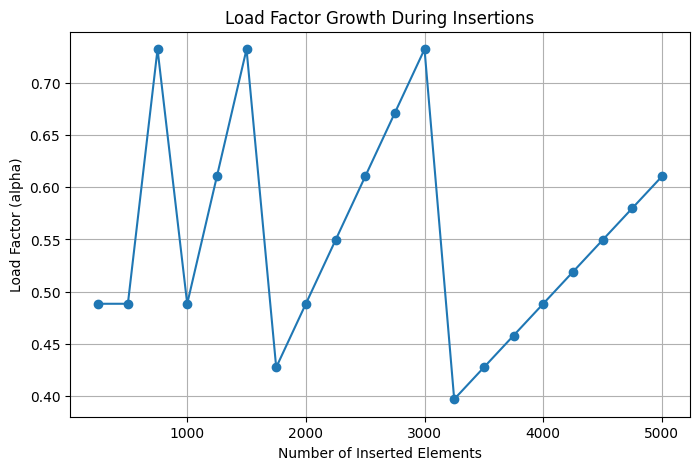

In [20]:
"""
Plot how the load factor changes as the number of inserted elements grows.
"""

plt.figure(figsize=(8, 5))
plt.plot(growth_df["Inserted Elements"], growth_df["Load Factor (alpha)"], marker="o")
plt.title("Load Factor Growth During Insertions")
plt.xlabel("Number of Inserted Elements")
plt.ylabel("Load Factor (alpha)")
plt.grid(True)
plt.show()

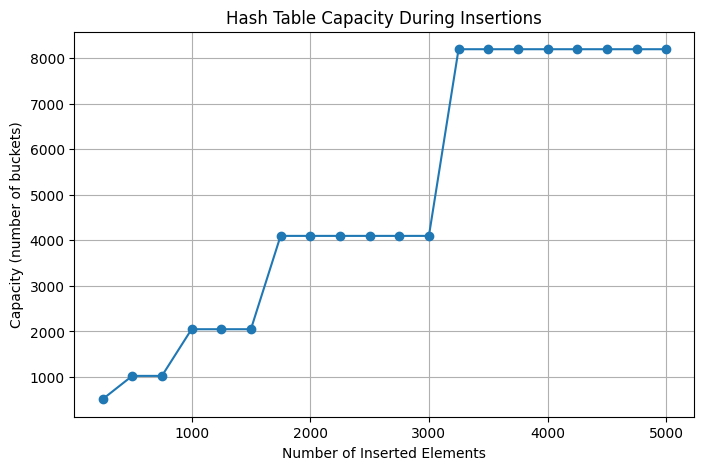

In [21]:
"""
Plot how the table capacity changes during insertions.

The step-like pattern should show when dynamic resizing occurs.
"""

plt.figure(figsize=(8, 5))
plt.plot(growth_df["Inserted Elements"], growth_df["Capacity (m)"], marker="o")
plt.title("Hash Table Capacity During Insertions")
plt.xlabel("Number of Inserted Elements")
plt.ylabel("Capacity (number of buckets)")
plt.grid(True)
plt.show()

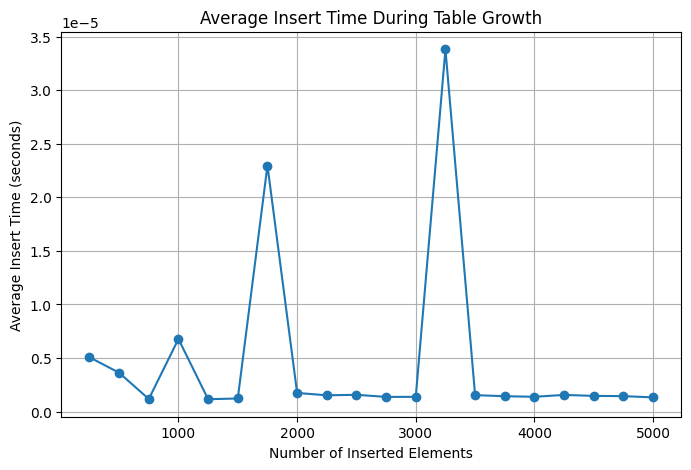

In [22]:
"""
Plot the average insert time measured over each checkpoint block.

Because resizing occasionally takes extra work, some blocks may show
slightly higher average insertion times.
"""

plt.figure(figsize=(8, 5))
plt.plot(growth_df["Inserted Elements"], growth_df["Average Insert Time (s)"], marker="o")
plt.title("Average Insert Time During Table Growth")
plt.xlabel("Number of Inserted Elements")
plt.ylabel("Average Insert Time (seconds)")
plt.grid(True)
plt.show()

In [23]:
"""
Measure average search and delete times on the populated table.

For searching:
- half the queries are for keys that exist
- half are for keys that do not exist

For deletion:
- use a fresh table copy so the experiment does not destroy the main one
"""

def measure_hash_operation_times(ht, existing_keys, num_trials=1000):
    """
    Measure average search and delete time.

    Parameters:
        ht (HashTableChaining): Populated hash table
        existing_keys (list): Keys that are known to exist
        num_trials (int): Number of measured operations

    Returns:
        dict: Average timings for successful search, unsuccessful search, and delete
    """

    # Successful search timing
    successful_search_total = 0.0
    for _ in range(num_trials):
        key = random.choice(existing_keys)

        start_time = time.perf_counter()
        ht.search(key)
        end_time = time.perf_counter()

        successful_search_total += (end_time - start_time)

    avg_successful_search = successful_search_total / num_trials

    # Unsuccessful search timing
    unsuccessful_search_total = 0.0
    for i in range(num_trials):
        missing_key = f"missing_key_{i}"

        start_time = time.perf_counter()
        ht.search(missing_key)
        end_time = time.perf_counter()

        unsuccessful_search_total += (end_time - start_time)

    avg_unsuccessful_search = unsuccessful_search_total / num_trials

    # Delete timing on a fresh copy of the table
    delete_ht = HashTableChaining(
        initial_capacity=ht.capacity,
        load_factor_threshold=ht.load_factor_threshold
    )

    # Reinsert all existing items into the fresh table
    for key in existing_keys:
        delete_ht.insert(key, 1)

    delete_total = 0.0
    delete_keys = existing_keys[:min(num_trials, len(existing_keys))]

    for key in delete_keys:
        start_time = time.perf_counter()
        delete_ht.delete(key)
        end_time = time.perf_counter()

        delete_total += (end_time - start_time)

    avg_delete = delete_total / len(delete_keys)

    return {
        "Average Successful Search Time (s)": avg_successful_search,
        "Average Unsuccessful Search Time (s)": avg_unsuccessful_search,
        "Average Delete Time (s)": avg_delete
    }

In [24]:
"""
Run the operation timing measurements and display them as a table.
"""

operation_results = measure_hash_operation_times(
    final_ht,
    inserted_keys,
    num_trials=1000
)

operation_df = pd.DataFrame([operation_results])
operation_df

,Average Successful Search Time (s),Average Unsuccessful Search Time (s),Average Delete Time (s)
0,0.000002,0.000003,0.000002


## Interpretation of Hash Table Experiment Results

The growth plots and timing results support the theoretical analysis.

### Load factor behavior
The load factor increased as elements were inserted, but resizing prevented it from growing without limit.

### Capacity behavior
The capacity increased in steps, which confirms that dynamic resizing was triggered as intended.

### Insertion behavior
The average insertion time remained small overall. Some intervals may show slightly higher cost because resizing requires rehashing all existing elements, but this does not happen on every insertion.

### Search and delete behavior
The average times for search and delete remained small, which is consistent with the expected time of \(O(1 + \alpha)\) when the load factor is kept under control.

### Overall conclusion
The practical behavior of the implementation matches the theory: chaining works well when the hash function distributes keys reasonably and resizing keeps the load factor from becoming too large.

In [25]:
"""
Save the experimental results so they can be included in the GitHub repo.
"""

growth_df.to_csv("hash_table_growth_results.csv", index=False)
operation_df.to_csv("hash_table_operation_results.csv", index=False)

print("Saved:")
print("- hash_table_growth_results.csv")
print("- hash_table_operation_results.csv")

Saved:
- hash_table_growth_results.csv
- hash_table_operation_results.csv
